# Building Mathematical Models with JijModeling + OMMX Adapter and Optimization with OpenJij
In this tutorial, we explain the process of formulating a mathematical model using JijModeling, converting it to QUBO, and solving it with OpenJij.

First, let's install the necessary packages.
We install [JijModeling](https://jij-inc-jijmodeling-tutorials-en.readthedocs-hosted.com/en/latest/introduction.html), a module for easily building mathematical models, and OMMX-OpenJij-Adapter for converting between OpenJij's I/O format and OMMX.
These can be installed using `pip`.

In [1]:
# !pip install jijmodeling ommx-openjij-adapter

## Traveling Salesman Problem (TSP)
We discuss the traveling salesman problem (TSP) as an example of a constrained optimization problem.
The TSP is the problem of finding the shortest route for a salesman who must visit each of the given cities exactly once and return to the starting city.

### Constraints
In this problem, there are two constraints: a location constraint stating that each city can only be visited once, and a time constraint stating that since there is only one salesman, he can only be in one city at a given time.

Using a binary variable where $x_{i,t}=1$ when visiting city $i$ at time $t$ and $x_{i,t}=0$ otherwise, the above two constraints can be written as:


$$\text{Location constraint : }\sum_{t=0}^{N-1} x_{i,t}=1 \quad \forall i$$

$$\text{Time constraint : }\sum_{i=0}^{N-1} x_{i,t}=1 \quad \forall t$$

### Objective Function
The TSP is a problem of finding the shortest route.
If $d_{ij}$ is the distance between cities $i$ and $j$, the distance traveled when visiting city $i$ at time $t$ and city $j$ at time $t+1$ is:

$$d_{ij}x_{i,t}x_{j,t+1}$$

The sum of the above,

$$\sum_{i=0}^{N-1}\sum_{j=0}^{N-1} \sum_{t=0}^{N-1} d_{ij}x_{i,t}x_{j,(t+1) \bmod N}$$

is the total distance traveled, which is the objective function we wish to minimize.

To perform Ising optimization as described in the previous tutorials, a mathematical model with such constraints must be converted to an Ising Hamiltonian or QUBO Hamiltonian.
Doing such work by hand is tedious and may introduce bugs between the actual mathematical model and QUBO.
JijModeling can do all this work automatically.
It can code the mathematical model constructed as described above and automatically convert it to QUBO.
Here, we explain how to use JijModeling, using the TSP described above as an example.

## Modeling with JijModeling

First, we use JijModeling to describe the mathematical formulas of the problem.
Unlike common modelers for mathematical optimization, JijModeling builds the mathematical model independently from the problem instance data.
By constructing the mathematical model this way, the generality of the model is ensured, and mathematical equations can be described intuitively, just like writing equations on paper.
Furthermore, the mathematical model described in JijModeling can be checked in LaTeX on the notebook.

Here, we will go through the construction of mathematical models with JijModeling step by step.

First, let us define the variables for describing the problem.

In [2]:
import jijmodeling as jm

problem = jm.Problem("TSP")

N = problem.Natural("N")
d = problem.Float("d", shape=(N, N))
x = problem.BinaryVar("x", shape=(N, N))

Here, `jm.Problem` defines the problem with the name TSP.

`problem.Natural` and `problem.Float` represent constants, used here to represent the number of cities $N$ and the distance matrix $d$.
In the TSP, various problems are represented by varying the distance matrix and number of cities.

Binary variables are represented by `problem.BinaryVar`.
Here we define a binary variable of $N\times N$.


In JijModeling, we add objective functions and constraints to the `jm.Problem`.

### Objective Function
Next, let us set the objective function.

In [3]:
problem += jm.sum(
    jm.product(N, N, N),
    lambda i, j, t: d[i, j] * x[i, t] * x[j, (t + 1) % N],
)

The sum can be expressed using `jm.sum`.
The first argument of `jm.sum` is the domain to sum over. Since the TSP objective function sums over three indices, we specify the Cartesian product with `jm.product(N, N, N)` and describe the expression for each index using a lambda expression.

Let us check the mathematical model so far through its LaTeX display.

In [4]:
problem

Problem(name="TSP", sense=MINIMIZE, objective=sum(set((N, N, N)).map(lambda ((i, j, t): Tuple[natural, natural, natural]): d[i, j] * x[i, t] * x[j, (t + 1) % N])), constraints=[])

### Constraints

Next, let us add the constraints.

In [5]:
# Constraint 1: one-hot location constraint
problem += problem.Constraint(
    "one-city",
    lambda t: jm.sum(N, lambda i: x[i, t]) == 1, domain=N
)

# Constraint 2: one-hot time constraint
problem += problem.Constraint(
    "one-time",
    lambda i: jm.sum(N, lambda t: x[i, t]) == 1, domain=N
)

Constraints can be expressed using `problem.Constraint`.
The first argument is the name of the constraint, and the second argument is the mathematical expression of the constraint.

Here, the constraint named `"one-city"` defines that each city $i$ is visited exactly once.
And the constraint named `"one-time"` sets the condition that only one city is visited at each time step $t$.

Let us check the mathematical model with the added constraints.

In [6]:
problem

Problem(name="TSP", sense=MINIMIZE, objective=sum(set((N, N, N)).map(lambda ((i, j, t): Tuple[natural, natural, natural]): d[i, j] * x[i, t] * x[j, (t + 1) % N])), constraints={one-city: [Constraint(name="one-city", , lambda t: sum(N.map(lambda (i: natural): x[i, t])) == 1, domain=set(N)),],one-time: [Constraint(name="one-time", , lambda i: sum(N.map(lambda (t: natural): x[i, t])) == 1, domain=set(N)),],})

We can see that the same mathematical expression as in the explanation is displayed.

This completes the construction of the mathematical model.
As shown above, JijModeling allows you to code mathematical models by comparing them with the formulas on paper.

## Creating an Instance
Now that we have the mathematical model, the next step is to create data for the problem.
Here we will solve a simple problem with 7 cities and random distances between cities.

(0.0, 1.0)

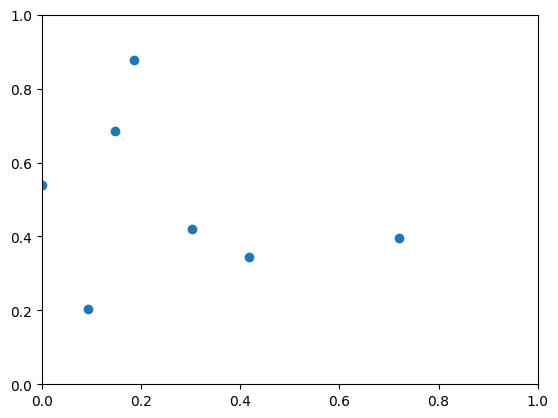

In [7]:
import matplotlib.pyplot as plt
import numpy as np

inst_N = 7
np.random.seed(1)

x_pos = np.random.rand(inst_N)
y_pos = np.random.rand(inst_N)

plt.plot(x_pos, y_pos, 'o')
plt.xlim(0, 1)
plt.ylim(0, 1)

Since we assign data to the `problem.Natural` and `problem.Float` variables used in the mathematical model, we need to pass the data in a dictionary with the variable names as keys.
In this problem, we need to pass values for `N` and `dist`.

In [8]:
XX, XX_T = np.meshgrid(x_pos, x_pos)
YY, YY_T = np.meshgrid(y_pos, y_pos)
inst_d = np.sqrt((XX - XX_T)**2 + (YY - YY_T)**2)
instance_data = {"N": inst_N, "d": inst_d}
instance_data

{'N': 7,
 'd': array([[0.        , 0.30759475, 0.45952133, 0.13629233, 0.43406434,
         0.35402107, 0.58040301],
        [0.30759475, 0.        , 0.73408488, 0.41859314, 0.64201675,
         0.6567735 , 0.71897319],
        [0.45952133, 0.73408488, 0.        , 0.32503125, 0.20721367,
         0.34684999, 0.38700806],
        [0.13629233, 0.41859314, 0.32503125, 0.        , 0.30817754,
         0.30035264, 0.4733741 ],
        [0.43406434, 0.64201675, 0.20721367, 0.30817754, 0.        ,
         0.48383715, 0.19690151],
        [0.35402107, 0.6567735 , 0.34684999, 0.30035264, 0.48383715,
         0.        , 0.6801809 ],
        [0.58040301, 0.71897319, 0.38700806, 0.4733741 , 0.19690151,
         0.6801809 , 0.        ]])}

## Converting to OMMX Instance
Now that we have prepared the mathematical model and data, we will create an OMMX Instance object by substituting the `instance_data` into the model described in JijModeling.

`OMMX Instance` is an object that follows the data standard representing mathematical model instances as specified by [OMMX](https://github.com/Jij-Inc/ommx), a common format for data exchange between modeler<>solver and modeler<>modeler in mathematical optimization. For more information about JijModeling and OMMX conversion, please refer to the [JijModeling documentation](https://jij-inc-jijmodeling-tutorials-en.readthedocs-hosted.com/en/latest/introduction.html) or [OMMX documentation](https://jij-inc.github.io/ommx/en/introduction.html).

In [9]:
# Substitute instance_data into problem to get OMMX instance
instance = problem.eval(instance_data)

At this stage, `instance` is still constrained optimization data. Let us briefly check its contents.

In [10]:
instance.decision_variables_df.head(5)

,kind,lower,upper,name,subscripts,description,substituted_value,parameters.subscripts
id,,,,,,,,
0,Binary,0.0,1.0,x,"[0, 0]",<NA>,<NA>,"[0,0]"
1,Binary,0.0,1.0,x,"[0, 1]",<NA>,<NA>,"[0,1]"
2,Binary,0.0,1.0,x,"[0, 2]",<NA>,<NA>,"[0,2]"
3,Binary,0.0,1.0,x,"[0, 3]",<NA>,<NA>,"[0,3]"
4,Binary,0.0,1.0,x,"[0, 4]",<NA>,<NA>,"[0,4]"


In [11]:
instance.constraints_df

,equality,type,used_ids,name,subscripts,description
id,,,,,,
0,=0,Linear,"{0, 35, 7, 42, 14, 21, 28}",one-city,[0],<NA>
1,=0,Linear,"{1, 36, 8, 43, 15, 22, 29}",one-city,[1],<NA>
2,=0,Linear,"{2, 37, 9, 44, 16, 23, 30}",one-city,[2],<NA>
3,=0,Linear,"{3, 38, 10, 45, 17, 24, 31}",one-city,[3],<NA>
4,=0,Linear,"{32, 4, 39, 11, 46, 18, 25}",one-city,[4],<NA>
5,=0,Linear,"{33, 5, 40, 12, 47, 19, 26}",one-city,[5],<NA>
6,=0,Linear,"{34, 6, 41, 13, 48, 20, 27}",one-city,[6],<NA>
7,=0,Linear,"{0, 1, 2, 3, 4, 5, 6}",one-time,[0],<NA>
8,=0,Linear,"{7, 8, 9, 10, 11, 12, 13}",one-time,[1],<NA>


We can confirm that binary variables and constraints have been assigned.
Next, let's convert the OMMX Instance to QUBO. The OMMX Instance is converted to QUBO using the penalty method.
Running `instance.to_qubo()` performs the conversion. For details about to_qubo, please refer to the [to_qubo API Reference](https://jij-inc.github.io/ommx/python/ommx/autoapi/ommx/v1/index.html#ommx.v1.Instance.to_qubo). If you want to adjust the penalty coefficient weights, you can use `uniform_penalty_weight` to adjust all penalty coefficients uniformly. Alternatively, you can specify `penalty_weights: dict[int, float]` using the Constraint table IDs as keys to individually adjust penalty coefficients for specific constraints. If not specified, all penalty coefficients will default to 1.0.

In [12]:
qubo, const = instance.to_qubo(uniform_penalty_weight=0.8)

## Running Optimization with OpenJij

Using the QUBO obtained above, we can perform optimization calculations as before.

In [13]:
from openjij import SASampler

sampler = SASampler()
res = sampler.sample_qubo(Q=qubo, num_reads=10)

Running optimization with OpenJij returns a sequence of 0s and 1s, which is difficult to read. Let's use ommx-openjij-adapter to verify if the constraints are satisfied and convert the results into a more usable format.

In [14]:
from ommx_openjij_adapter import OMMXOpenJijSAAdapter

# Adapter handles conversion between OMMX Instance and OpenJij
adapter = OMMXOpenJijSAAdapter(instance)

# Convert OpenJij results to OMMX SampleSet.
# At this point, it calculates the objective function and checks if constraints are satisfied.
sampleset = adapter.decode_to_sampleset(res)

`sampleset` is a format that contains multiple solutions. We select the best solution from these.
`.best_feasible` selects the solution with the smallest objective function value among feasible solutions that satisfy the constraints. However, when using `instance.to_qubo`, all constraints are removed and combined into the objective function as penalties, so this method cannot select feasible solutions.
The operation of removing constraints and combining them as penalties is called relaxation. The `instance` has been relaxed by calling `.to_qubo`. However, we typically want to verify if the original constraints are satisfied. Even though constraints appear removed after relaxation, they are actually preserved internally. Therefore, `.best_feasible_unrelaxed` is available to extract feasible solutions based on the pre-relaxation state. After converting to QUBO, use this method to select the solution with the best objective function value from among feasible solutions.

In [15]:
best_sample = sampleset.best_feasible_unrelaxed

`decision_variables_df` can be used to retrieve the results from OpenJij converted back to the original mathematical model variables in an easy-to-read format.

In [16]:
df = best_sample.decision_variables_df
nonzero_keys = {tuple(row["subscripts"]) for _, row in df.iterrows() if row["value"] > 0.5}
nonzero_keys

{(0, 3), (1, 1), (2, 0), (3, 4), (4, 5), (5, 2), (6, 6)}

`sampleset.constraints_df` allows you to check the original constraints and their values. The `value.` field contains the value of the left side minus the right side of the constraint equation. If the constraint is satisfied, it will be 0; if not satisfied, it will be a non-zero value. The `feasible.` field contains a boolean value indicating whether the constraint is satisfied. Since we used `.best_feasible_unrelaxed`, we can confirm that all constraints are satisfied.

Additionally, `removed_reason` indicates that this constraint was combined into the objective function as a penalty using the `uniform_penalty_method`.

In [17]:
sampleset.constraints_df

,equality,used_ids,name,subscripts,description,removed_reason,value.0,value.1,value.2,value.3,...,feasible.0,feasible.1,feasible.2,feasible.3,feasible.4,feasible.5,feasible.6,feasible.7,feasible.8,feasible.9
id,,,,,,,,,,,,,,,,,,,,,
0,=0,"{0, 35, 21, 7, 42, 28, 14}",one-city,[0],None,uniform_penalty_method,1.0,0.0,0.0,0.0,...,False,True,True,True,True,False,True,False,True,True
1,=0,"{1, 36, 22, 8, 43, 29, 15}",one-city,[1],None,uniform_penalty_method,-1.0,0.0,0.0,0.0,...,False,True,True,True,True,True,True,True,True,False
2,=0,"{16, 2, 37, 23, 9, 44, 30}",one-city,[2],None,uniform_penalty_method,0.0,1.0,1.0,0.0,...,True,False,False,True,True,True,True,True,True,True
3,=0,"{17, 3, 38, 24, 10, 45, 31}",one-city,[3],None,uniform_penalty_method,0.0,-1.0,-1.0,0.0,...,True,False,False,True,True,False,True,False,True,True
4,=0,"{32, 18, 4, 39, 25, 11, 46}",one-city,[4],None,uniform_penalty_method,0.0,0.0,0.0,0.0,...,True,True,True,True,True,True,True,True,True,False
5,=0,"{33, 19, 5, 40, 26, 12, 47}",one-city,[5],None,uniform_penalty_method,0.0,1.0,0.0,0.0,...,True,False,True,True,False,True,False,True,True,False
6,=0,"{48, 34, 20, 6, 41, 27, 13}",one-city,[6],None,uniform_penalty_method,0.0,0.0,0.0,0.0,...,True,True,True,True,False,True,True,True,True,True
7,=0,"{0, 1, 2, 3, 4, 5, 6}",one-time,[0],None,uniform_penalty_method,0.0,0.0,0.0,0.0,...,True,True,True,True,True,True,True,False,True,True
8,=0,"{7, 8, 9, 10, 11, 12, 13}",one-time,[1],None,uniform_penalty_method,0.0,0.0,0.0,0.0,...,True,True,True,True,True,True,True,True,True,True


Let us visualize this solution.
First, we create the tour using `nonzero_keys`.

In [18]:
tour = [0 for _ in range(inst_N)]
for (i, t) in nonzero_keys:
    tour[t] = i
tour.append(tour[0])  # return from the last city to the first
tour

[2, 1, 5, 0, 3, 4, 6, 2]

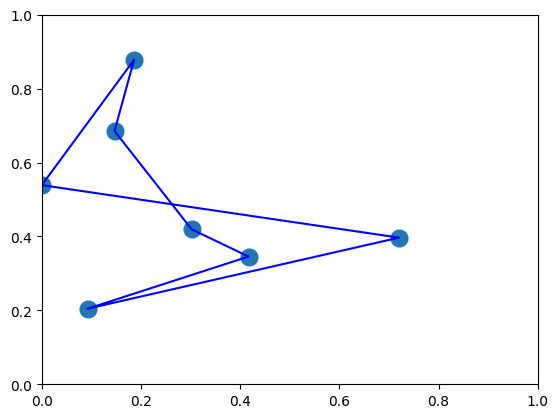

In [19]:
plt.plot(x_pos, y_pos, 'o',markersize=12)
plt.plot(x_pos[tour], y_pos[tour], 'blue')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

## Shortcut using OMMX-OpenJij-Adapter

In the tutorial above, we went through three steps: convert to QUBO -> optimize with OpenJij -> decode/evaluate with ommx-openjij-adapter. In fact, `ommx-openjij-adapter` allows you to perform all these steps at once (currently only for Simulated Annealing).

In [20]:
adapter = OMMXOpenJijSAAdapter(instance)
sampleset = adapter.sample(instance)

By using the `Adapter.sample` method, all the steps can be executed in a single line. Additionally, an `Adapter.solve` method is also provided, which filters the results from sampling to return only the best solution.